# 오차역전파법

앞 장에서 신경망의 가중치 매개변수의 기울기(정확히는 가중치 매개변수에 대한 손실 함수의 기울기)는 수치 미분을 사용해 구함   
수치 미분은 단순하고 구현하기도 쉽지만 계산 시간이 오래 걸린다는 단점이 있음

이번 장에서는 **가중치 매개변수의 기울기를 효율적으로 계산하는 오차역전파법(backpropagation)** 을 배울 예정

오차역전파법을 제대로 이해하는 방법은 두 가지가 있음   
하나는 수식을 통한 것, 다른 하나는 계산 그래프를 통한 것
- 수식을 통한 것이 일반적인 방법으로, 특히 기계학습을 다루는 책 대부분은 수식을 중심으로 이야기를 전개함
- 확실히 수식을 사용한 설명은 정확하고 간결하므로 올바른 방법이라 할 수 있음
- 하지만 너무 오랜만에 수식을 중심으로 생각하다 보면 본질을 놓치거나, 수많은 수식에 당황하는 일이 벌어지기도 함

그래서 이번 장에서는 계산 그래프를 사용해서 '시각적'으로 이해할 것   
그런 다음 실제로 코드를 작성해보면 더 깊이 이해하게 될 것

오차역전파법을 계산 그래프로 설명한다는 생각은 안드레 카패시의 블로그, 또 그와 페이페이 리 교수가 진행한 스탠퍼드 대학교의 딥러닝 수업 CS231n을 참고했음

> 오차역전파법을 풀어쓰면 '오차를 역(반대 방향)으로 전파하는 방법(backward propagation of errors)'   
> 너무 길고 쓸데없이 어려운 느낌이라 줄여서 '역전파법' 혹은 그냥 '역전파'라고 쓰기도 함

## 계산 그래프

- **계산 그래프(computational graph)** 는 계산 과정을 그래프로 나타낸 것
- 여기에서의 그래프는 우리가 잘 아는 그래프 자료구조로, 복수의 노드와 에지로 표현됨

이번 절에서는 계산 그래프에 친숙해지기 위한 간단한 문제를 풀어봄   
간단한 문제에서부터 한 단계씩 나아가면서 마지막에는 오차역전파법에 도달할 예정

### 계산 그래프로 풀다

간단한 문제를 그래프를 사용해서 풀어보기   
곧 보게 될 문제는 암산으로도 풀 정도로 간단하지만 지금의 목적은 계산 그래프에 익숙해지는 것   
계산 그래프는 뒤에 나올 복잡한 계산에서 진짜 위력을 발휘하므로, 지금 그 사용법을 익혀두기   

>> 문제 1: 현빈 군은 슈퍼에서 1개에 100원인 사과 2개를 샀습니다.   
>> 이때 지불 금액을 구하세요. 단, 소비세가 10% 부과됩니다.

- 계산 그래프는 계산 과정을 노드와 화살표로 표현함   
- 노드는 원으로 표기하고 원 안에 연산 내용을 적음   
- 또, 계산 결과를 화살표 위에 적어 각 노드의 계산 결과가 왼쪽에서 오른쪽으로 전해지게 함   
- 문제 1을 계산 그래프로 풀면    
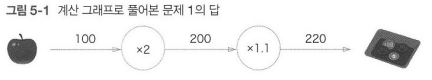   
- 그림과 같이 처음에 사과의 100원이 'X2' 노드로 흐르고, 200원이 되어 다음 노드로 전달됨
- 이제 200원이 'X1.1' 노드를 거쳐 220원이 됨   
- 따라서 이 계산 그래프에 따르면 최종 답은 220원이 됨

또한 그림에서는 'X2'와 'X1.1'을 각각 하나의 연산으로 취급해 원 안에 표기했지만, 곱셈인 'X'만을 연산으로 생각할 수도 있음   
이렇게 하면   
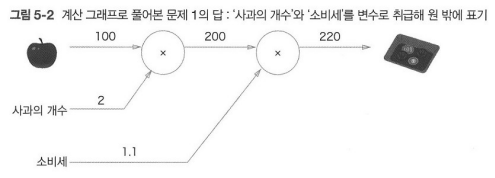   
그림처럼 '2'와 '1.1'은 각각 '사과의 개수'와 '소비세' 변수가 되어 원 밖에 표기하게 됨   

> 문제 2: 현빈 군은 슈퍼에서 사과를 2개, 귤을 3개 샀습니다.   
> 사과는 1개에 100원, 귤은 1개 150원입니다. 소비세가 10%일 때 지불 금액을 구하세요.

문제 2도 문제 1과 같이 계산 그래프로 풀어보기   
이때 계산 그래프는   
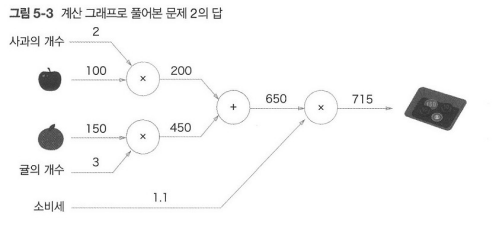   
- 이 문제에는 덧셈 노드인 '+'가 새로 등장하여 사과와 귤의 금액을 합산함
- 계산 그래프는 왼쪽에서 오른쪽으로 계산을 진행함 - 회로에 전류가 흐르듯 계산 결과가 왼쪽에서 오른쪽으로 전달된다고 생각하면 됨
- 계산 겨로가가 오른쪽 끝에 도착하면 끝
- 그래서 위 그림에서의 답은 715원

지금까지 살펴본 것처럼 계산 그래프를 이용한 문제풀이는 다음 흐름으로 진행됨   
1. 계산 그래프를 구성한다.
2. 그래프에서 계산을 왼쪽에서 오른쪽으로 진행한다.

여기서 2번째 '계산을 왼쪽에서 오른쪽으로 진행'하는 단계를 **순전파(forward propagastion)** 라고 함   
- 순전파는 계산 그래프의 출발점부터 종착점으로의 전파

순전파의 반대 방향(그림에서 말하면 오릉쪽에서 왼쪽)의 전파를 **역전파(backward propagastion)** 라고 함
- 역전파는 이후에 미분을 계산할 때 중요한 역할을 함

### 국소적 계산

계산 그래프의 특징은 '국소적 계산'을 전파함으로써 최종 결과를 얻는다는 점에 있음   
국소적이란 '자신과 직접 관련된 작은 범위'라는 뜻   
국소적 계산은 결국 전체에서 어떤 일이 벌어지든 상관없이 자신과 관련된 정보만으로 결과를 출력할 수 있다는 것

국소적 계산을 구체적인 예를 들어서 설명해보면
- 슈퍼마켓에서 사과 2개를 포함한 여러 식품을 구입하는 경우를 계산 그래프로 나타내 보면   
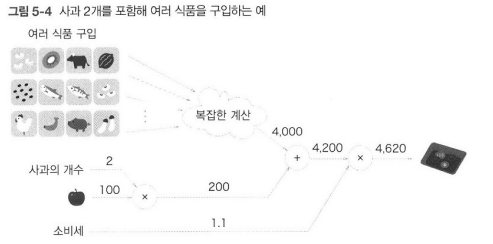   
- 그림에서는 여러 식품을 구입하여 (복잡한 계산을 거쳐) 총금액이 4,000원이 됨
- 여기에서 핵심은 각 노드에서의 계산은 국소적 계산이라는 점
- 가령 사과와 그외의 물품 값을 더하는 계산 (4,000 + 200 -> 4,200)은 4,000이라는 숫자가 어떻게 계산되었느냐와는 상관없이, 단지 두 숫자를 더하면 된다는 뜻
- 각 노드는 자신과 관련한 계산(이 예에서는 입력된 두 숫자의 덧셈) 외에는 아무것도 신경 쓸 게 없음

이처럼 계산 그래프는 국소적 계산에 집중함   
전체 계산이 제아무리 복잡하더라도 각 단계에서 하는 일은 해당 노드의 '국소적 계산'   
국소적인 계산은 단순하지만, 그 결과를 전달함으로써 전체를 구성하는 복잡한 계산을 해낼 수 있음   

> 비유하자면 복잡한 자동차 조립은 일반적으로 '조립 라인 작업'에 의한 분업으로 행해짐   
> 각 담당자(담당 기계)는 단순화된 일만 수행하며 그 일의 결과가 다음 담당자로 전달되어 최종적으로 차를 완성함   
> 계산 그래프도 복잡한 계산을 '단순하고 국소적 계산'으로 분할하고 조립 라인 작업을 수행하며 계산 결과를 다음 노드로 전달함   
> 복잡한 계산도 분해하면 단순한 계산으로 구성된다는 점은 자동차 조립과 마찬가지인 것

### 왜 계산 그래프로 푸는가?

계산 그래프의 이점
- 국소적 계산
    - 전체가 아무리 복잡해도 각 노드에서는 단순한 게산에 집중하여 문제를 단순화할 수 있음
- 계산 그래프는 중간 계산 결과를 모두 보관할 수 있음
    - 예를 들어 사과 2개까지 계산했을 때의 금액은 200원, 소비세를 더하기 전의 금액은 650원인 식
- 실제 계산 그래프를 사용하는 가장 큰 이유는 역전파를 통해 '미분'을 효율적으로 계산할 수 있다는 점에 있음

계산 그래프의 역전파를 설명하기 위해 문제 1을 다시 꺼내보면   
문제 1은 사과를 2개 사서 소비세를 포함한 최종 금액을 구하는 것   
여기서 가령 사과 가격이 오르면 최종 금액에 어떤 영향을 끼치는지 알고 싶다고 하면   
이는 '사과 가격에 대한 지불 금액의 미분'을 구하는 문제에 해당   
기호로 나타낸다면 사과 값을 x, 지불 금액을 L이라 했을 때 을 구하는 것   
이 미분 값은 사과 값이 '아주 조금' 올랐을 때 지불 금액이 얼마나 증가하느냐를 표시한 것

앞에서 말했듯이 '사과 가격에 대한 지불 금액의 미분'같은 값은 계산 그래프에서 역전파를 하면 구할 수 있음   
먼저 결과만을 나타내면 아래 그림처럼 계산 그래프 상의 역전파에 의해서 미분을 구할 수 있음(역전파가 어떻게 이뤄지느냐는 곧 설명함)   
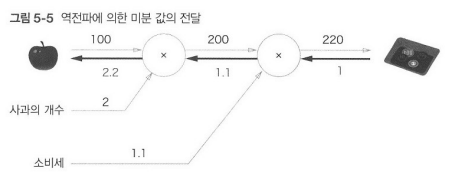   
- 그림과 같이 역전파는 순전파와는 반대 방향의 화살표(굵은 선)로 그림
- 이 전파는 '국소적 미분'을 전달하고 그 미분 값은 화살표의 아래에 적음   
- 이 예에서 역전파는 오른쪽에서 왼쪽으로 '1 -> 1.1 -> 2.2'순으로 미분 값을 전달함
- 이 결과로부터 '사과 가격에 대한 지불 금액의 미분'값은 2.2라 할 수 있음
    - 사과가 1우너 오르면 최종 금액은 2.2원 오른다는 뜻 (정확히는 사과 값이 아주 조금 오르면 최종 금액은 그 아주 작은 값의 2.2배만큼 오른다는 뜻)   

여기에서는 사과 가격에 대한 미분만 구했지만, '소비세에 대한 지불 금액의 미분'이나 '사과 개수에 대한 지불 금액의 미분'도 같은 순서로 구할 수 있음   
그리고 그때는 중간까지 구한 미분 결과를 공유할 수 있어서 다수의 미분을 효율적으로 계산할 수 있음   
이처럼 계산 그래프의 이점은 순전파와 역전파를 활용해서 각 변수의 미분을 효율적으로 구할 수 있다는 것

## 연쇄법칙

그동안 해온 계산 그래프의 순전파는 계산 결과를 왼쪽에서 오른쪽으로 전달함   
이 순서는 평소 하는 방식이닌 자연스럽게 느껴짐   
한편 역전파는 '국소적인 미분'을 순방향과는 반대인 오른쪽에서 왼쪽으로 전달함   
또한, 이 '국소적 미분'을 전달하는 원리는 **연쇄법칙(chain rule)** 에 따른 것   
이번 절에서는 연쇄법칙을 설명하고 그것이 계산 그래프 상의 역전파와 같다는 사실을 밝힐 예정

### 계산 그래프의 역전파

계산 그래프를 사용한 역전파의 예를 하나 살펴보기   
y = f(x)라는 계산의 역전파를 그림으로 그려보면   
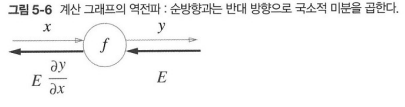   
- 그림과 같이 역전파의 계산 절차는 신호 E에 노드의 국소적 미분()을 곱한 후 다음 노드로 전달하는 것   
- 여기에서 말하는 국소적 미분은 순전파 때의 y = f(x) 계산의 미분을 구한다는 것이며, 이는 x에 대한 y의 미분 을 구한다는 뜻
    - 가령 y = f(x) = x^2 이라면  = 2x가 됨
- 그리고 이 국소적인 미분을 상류에서 전달된 값(이 예에서는 E)에 곱해 앞쪽 노드로 전달하는 것

이것이 역전파의 계산 순서인데, 이러한 방식을 따르면 목표로 하는 미분 값을 효율적으로 구할 수 있다는 것이 이 전파의 핵심   
왜 그런 일이 가능한가는 연쇄법칙의 원리로 설명할 수 있음

### 연쇄법칙이란?

연쇄법칙을 설명하려면 우선 함수 이야기부터 시작해야함   
**합성 함수** 란 여러 함수로 구성된 함수   
- 예를 들어 z = (x + y)^2 이라는 식은 아래 그림처럼 두 개의 식으로 구성됨   
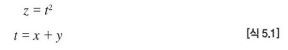   

연쇄법칙은 합성 함수의 미분에 대한 성질이며, 다음과 같이 정의됨   
> 합성 함수의 미분은 합성 함수를 구성하는 각 함수의 미분의 곱으로 나타낼 수 있다.   

이것이 연쇄법칙의 원리   
언뜻 어렵게 보이지만 간단한 성질   

- 위 식을 예로 설명하면, (x에 대한 z의 미분)은 (t에 대한 z의 미분)과 (x에 대한 t의 미분)의 곱으로 나타낼 수 있다는 것
- 수식으로 나타내면   
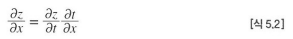   
- 위 식은 를 지울 수 있음   
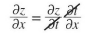   
- 그럼 연쇄법칙을 써서 미분 를 구해보면, 
- 가장 먼저 식 5.1의 국소적 미분(편미분)을 구함   
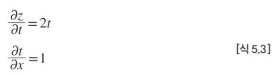   
- 위 식을 이용해 최종적으로 구하고 싶은 는 두 미분을 곱해 계산함   
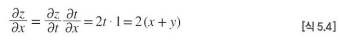

### 연쇄법칙과 계산 그래프

위에서 구한 최종 식의 연쇄법칙 계산을 계산 그래프로 나타내보기   
2제곱 계산을 '**2' 노드로 나타내면   
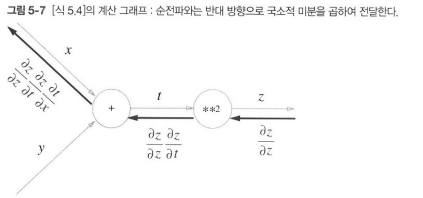   
- 그림과 같이 계산 그래프의 역전파는 오른쪽에서 왼쪽으로 신호를 전파함   
- 역전파의 계산 절차에서는 노드로 들어온 입력 신호에 그 노드의 국소적 미분(편미분)을 곱한 후 다음 노드로 전달함
    - 예를 들어 '**2' 노드에서의 역전파를 보면
    - 입력은 이며, 이에 국소적 미분인 (순전파 시에는 입력이 t이고 출력이 z이므로 이 노드에서 (국소적) 미분은 임)를 곱하고 다음 노드로 넘김
- 한 가지, 그림에서 역전파의 첫 신호인 의 값은 결국 1이라서 앞의 수식에서는 언급하지 않았음

그런데 그림에서 주목할 것은 맨 왼쪽 역전파   
이 계산은 연쇄법칙에 따르면 가 성립되어 'x에 대한 z의 미분'이 됨   
즉, 역전파가 하는 일은 연쇄법칙의 원리와 같다는 것   

그림에 식 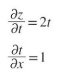의 결과를 대입하면 아래 그림이 되며, 을 구할 수 있음   
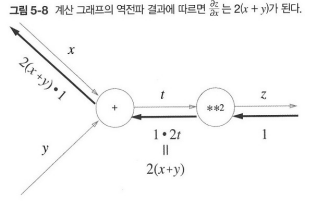

## 역전파

앞 절에서는 계산 그래프의 역전파가 연쇄법칙에 따라 진행되는 모습을 설명했음   
이번 절에서는 '+'와 'x' 등의 연산을 예로 들어 역전파의 구조를 설명함  

### 덧셈 노드의 역전파

여기에서는 z = x + y 라는 식을 대상으로 그 역전파를 살펴봄   
우선 z = x + y의 미분은 다음과 같이 해석적으로 계산할 수 있음   
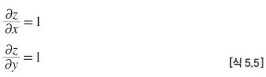   
- 식에서와 같이 와 는 모두 1이 됨
- 이를 계산 그래프로 나타내면   
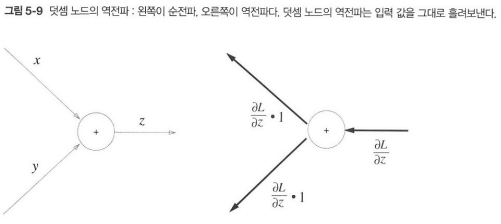   
- 그림과 같이 역전파 때는 상류에서 전해진 미분 (이 예에서는 )에 1을 곱하여 하류로 흘림
- 즉, 덧셈 노드의 역전파는 1을 곱하기만 할 뿐이므로 입력된 값을 그대로 다음 노드로 보내게 됨   
- 이 예에서는 상류에서 전해진 미분 값을 이라 했는데, 이는 아래 그림과 같이 최종적으로 L이라는 값을 출력하는 큰 계산 그래프를 가정하기 때문   
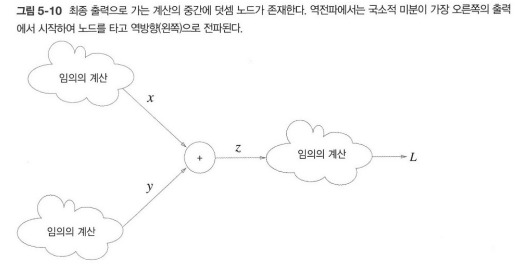   
- z = x + y 계산은 그 큰 계산 그래프의 중간 어딘가에 존재하고, 상류로부터 값이 전해진 것
- 그리고 다시 하류로 과 값을 전달하는 것


이제 구체적인 예를 하나 살펴보면   
- 가령 '10 + 5 = 15'라는 계산이 있고, 상류에서 1.3이라는 값이 흘러옴   
- 이를 계산 그래프로 그리면   
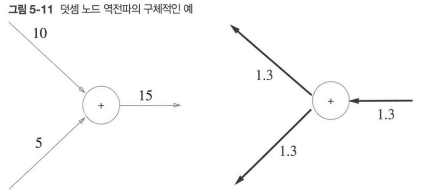   
- 덧셈 노드 역전파는 입력 신호를 다음 노드로 출력할 뿐이므로 그림처럼 1.3을 그대로 다음 노드로 전달함

### 곱셈 노드의 역전파

z = xy라는 식을 생각해보면   
이 식의 미분은 다음과 같음   
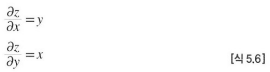   
위 식에서 계산 그래프는 다음과 같이 그릴 수 있음   
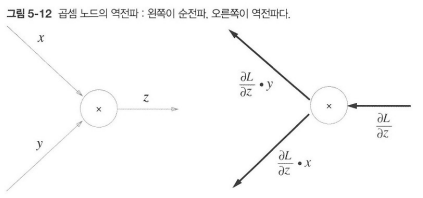   
- 곱셈 노드 역전파는 상류의 값에 순전파 때의 입력 신호들을 '서로 바꾼 값'을 곱해서 하류로 보냄
- 서로 바꾼 값이란 그림처럼 순전파 때 x였다면 역전파에서는 y, 순전파 때 y였다면 역전파에서는 x로 바꾼다는 의미

그럼 구체적인 예를 하나 보면
- 가령 '10 X 5 = 50'이라는 계산이 있고, 역전파 때 상류에서 1.3값이 흘러온다고 하면   
- 이를 계산 그래프로 그리면   
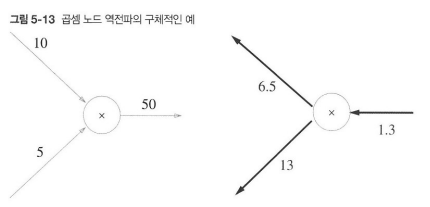   
- 곱셈의 역전파에서는 입력 신호를 바꾼 값을 곱하여 하나는 1.3 X 5 = 6.5, 다른 하나는 1.3 X 10 = 13이 됨
- 덧셈의 역전파에서는 상류의 값을 그대로 흘려보내서 순방향 입력 신호의 값은 필요하지 않았지만, 곱셈의 역전파는 순방향 입력 신호의 값이 필요함
- 그래서 곱셈 노드를 구현할 때는 순전파의 입력 신호를 변수에 저장해둠

### 사과 쇼핑의 예

이번 장을 시작할 때 봤던 사과 쇼핑 예를 다시 살펴봄   

이 문제에서는 사과의 가격, 사과의 개수, 소비세라는 세 변수 각각이 최종 금액에 어떻게 영향을 주느냐를 풀고자 함   
이는 '사과 가격에 대한 지불 금액의 미분', '사과 개수에 대한 지불 금액의 미분', '소비세에 대한 지불 금액의 미분'을 구하는 것에 해당함   
이를 계산 그래프의 역전파를 사용해서 풀면   
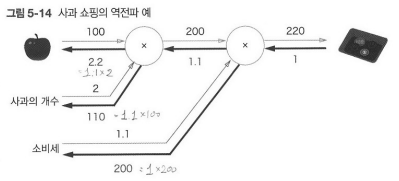   
- 지금까지 설명한 바와 같이 곱셈 노드의 역전파에서는 입력 신호를 서로 바꿔서 하류로 흘림
- 그림의 결과를 보면 사과 가격의 미분은 2.2, 사과 개수의 미분은 110, 소비세의 미분은 200
- 이는 소비세와 사과 가격이 같은 양만큼 오르면 최종 금액에는 소비세가 200의 크기로, 사과 가격이 2.2의 크기로 영향을 준다고 해석할 수 있음
- 단, 이 예에서 소비세와 사과 가격은 단위가 다르니 주의해야 함 (소비세는 100%, 사과 가격 1은 1원)

마지막으로 '사과와 귤 쇼핑'의 역전파를 풀어보면   
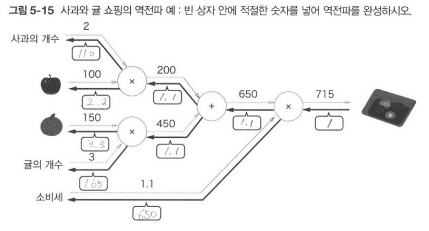   
- 그림의 빈 칸에 적당한 숫자를 넣어 각 변수의 미분을 구해보면   
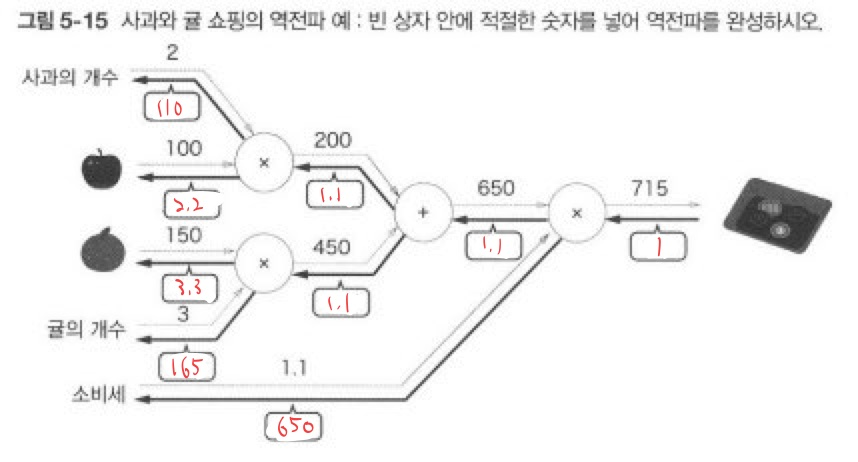

## 단순한 계층 구현하기

이번 절에서는 지금까지 보아온 '사과 쇼핑' 예를 파이썬으로 구현   
여기에서는 계산 그래프의 곱셈 노드를 'MulLayer', 덧셈 노드를 'AddLayer'라는 이름으로 구현함   

> 다음 절에서는 신경망을 구성하는 '계층' 각각을 하나의 클래스로 구현함   
> 여기에서 말하는 '계층'이란 신경망의 기능 단위   
> 예를 들어 시그모이드 함수를 위한 Sigmoid, 행렬 곱을 위한 Affine 등의 기능을 계층 단위로 구현함   
> 그래서 이번 절에서도 곱셈 노드와 덧셈 노드를 '계층' 단위로 구현함

### 곱셈 계층

모든 계층은 forward()와 backward()라는 공통의 메서드(인터페이스)를 갖도록 구현할 것   
- forward()는 순전파, backward()는 역전파를 처리함

곱셈 계층은 MulLayer하는 이름의 클래스로 다음과 같이 구현할 수 있음

In [2]:
class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None

    def forward(self, x, y):
        self.x = x
        self.y = y
        out = x * y

        return out
    
    def backward(self, dout):
        dx = dout * self.y
        dy = dout * self.x

        return dx, dy

- \_\_init__()에서는 인스턴스 변수인 x와 y를 초기화함
    - 이 두 변수는 순전파 시의 입력 값을 유지하기 위해서 사용함
- forward()에서는 z와 y를 인수로 받고 두 값을 곱해서 반환함
- backward()에서는 상류에서 넘어온 미분(dout)에 순전파 때의 값을 '서로 바꿔' 곱한 후 하류로 흘림

이 MulLayer를 사용해서 앞에서 본 '사과 쇼핑'을 구현해보기   
앞 절에서는 계산 그래프의 순전파와 역전파를 써서 아래 그림과 같이 계산할 수 있었음   
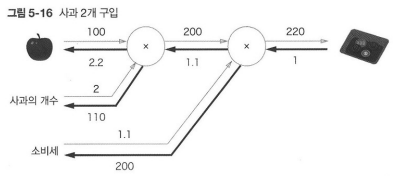   

In [3]:
apple = 100
apple_num = 2
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

print(price)

220.00000000000003


또 각 변수에 대한 미분은 backward()에서 구할 수 있음

In [4]:
# 역전파
dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(dapple, dapple_num, dtax)

2.2 110.00000000000001 200


- backward() 호출 순서는 forward() 때와는 반대
- 또, backward()가 받는 인수는 '순전파의 출력에 대한 미분'임에 주의
    - 가령 mul_apple_layer라는 곱셈 계층은 순전파 때는 apple_price를 출력하지만, 역전파 때는 apple_price의 미분 값인 dapple_price를 인수로 받음
- 마지막으로, 이 코드를 실행한 결과는 위에 그림의 결과와 같음

### 덧셈 계층

뎃셈 계층은 다음과 같이 구현할 수 있음

In [5]:
class AddLayer:
    def __init__(self):
        pass

    def forward(self, x, y):
        out = x + y
        return out
    
    def backward(self, dout):
        dx = dout * 1
        dy = dout * 1
        return dx, dy

- 덧셈 계층에서는 초기화가 필요 없으니 \_\_init__()에서는 아무 일도 하지 않음 (pass가 '아무것도 하지 말라'는 명령)
- 덧셈 계층의 forward()에서는 입력받은 두 인수 x, y를 더해서 반환함
- backward()에서는 상류에서 내려온 미분(dout)을 그대로 하류로 흘림

위의 덧셈 계층과 곱셈 계층을 사용하여 사과 2개와 귤 3개를 사는 상황을 구현   
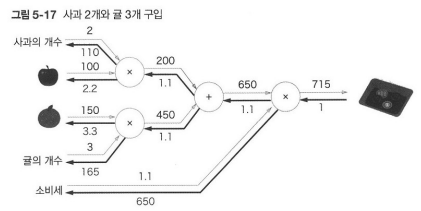   
그림의 계산 그래프를 파이썬으로 구현하면

In [6]:
apple = 100
apple_num = 2
orange = 150
orange_num = 3
tax = 1.1

# 계층들
mul_apple_layer = MulLayer()
mul_orange_layer = MulLayer()
add_apple_orange_layer = AddLayer()
mul_tax_layer = MulLayer()

# 순전파
apple_price = mul_apple_layer.forward(apple, apple_num)
orange_price = mul_orange_layer.forward(orange, orange_num)
all_price = add_apple_orange_layer.forward(apple_price, orange_price)
price = mul_tax_layer.forward(all_price, tax)

# 역전파
dprice = 1
dall_price, dtax = mul_tax_layer.backward(dprice)
dapple_price, dorange_price = add_apple_orange_layer.backward(dall_price)
dorange, dorange_num = mul_orange_layer.backward(dorange_price)
dapple, dapple_num = mul_apple_layer.backward(dapple_price)

print(price)
print(dapple_num, dapple, dorange, dorange_num, dtax)

715.0000000000001
110.00000000000001 2.2 3.3000000000000003 165.0 650


- 코드가 다소 길어졌지만, 하나하나의 명령은 단순함
- 필요한 계층을 만들어 순전파 메서드인 forward()를 적절한 순서로 호출함
- 그런 다음 순전파와 반대 순서로 역전파 메서드인 backward()를 호출하면 원하는 미분이 나옴

이처럼 계산 그래프에서의 계층(여기에서는 곱셈과 덧셈)은 쉽게 구현할 수 있으며, 이를 사용해 복잡한 미분도 계산할 수 있음   
다음 절에서는 신경망에서 사용하는 계층을 구현

## 활성화 함수 계층 구현하기

계산 그래프를 신경망에 적용   
여기에서는 신경망을 구성하는 층(계층) 각각을 클래스 하나로 구현함   
우선은 활성화 함수인 ReLU와 Sigmoid 계층을 구현

### ReLU 계층

활성화 함수로 사용되는 ReLU의 수식은 다음과 같음   
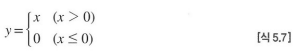   
위 식에서 x에 대한 y의 미분은   
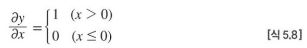   
- 위 식에서와 같이 순전파 때의 입력인 x가 0보다 크면 역전파는 상류의 값을 그대로 하류로 흘림
- 반면, 순전파 때의 입력인 x가 0 이하면 역전파 때는 하류로 신호를 보내지 않음 (0을 보냄)
- 계산 그래프로 그리면   
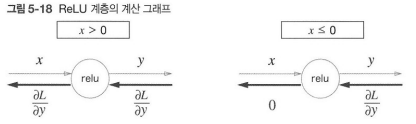   


이제 이 ReLU 계층을 구현해보기   
신경망 계층의 forward()와 backward() 함수는 넘파이 배열을 인수로 받는다고 가정

In [7]:
class Relu:
    def __init__(self):
        self.mask = None
    
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

- Relu 클래스는 mask라는 인스턴스 변수를 가짐
- mask는 True/False로 구성된 넘파이 배열로, 순전파의 입력인 x의 원소 값이 0 이하인 인덱스는 True, 그 외(0보다 큰 원소)는 False로 유지함

예컨대 mask 변수는 다음 예와 같이 True/False로 구성된 넘파이 배열을 유지함

In [8]:
import numpy as np

x = np.array([[1.0, -0.5], [-2.0, 3.0]])
print(x)

mask = (x <= 0)
print(mask)

[[ 1.  -0.5]
 [-2.   3. ]]
[[False  True]
 [ True False]]


- 위 그림과 같이 순전파 때의 입력 값이 0 이하면 역전파 때의 값은 0이 돼야 함
- 그래서 역전파 때는 순전파 때 만들어둔 mask를 써서 mask의 원소가 True인 곳에는 상류에서 전파된 dout을 0으로 설정함

> ReLU 계층은 전기 회로의 '스위치'에 비유할 수 있음   
> 순전파 때 전류가 흐르고 있으면 스위치를 ON으로 하고, 흐르지 않으면 OFF로 함   
> 역전파 때는 스위치가 ON이라면 그대로 흐르고, OFF면 더 이상 흐르지 않음

### Sigmoid 계층

시그모이드 함수는 다음 식을 의미하는 함수   
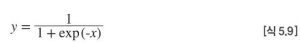   
위 식을 계산 그래프로 그리면   
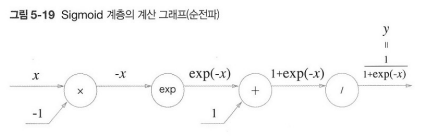   
- 그림에는 'x'와 '+' 노드 말고도 'exp'와 '/' 노드가 새롭게 등장함
- 'exp' 노드는 y = exp(x) 계산을 수행하고 '/' 노드는 y = 1/x 계산을 수행함

그림과 같이 위 식의 계산은 국소적 계산의 전차로 이뤄짐   
이제 그림의 역전파를 알아보면   
여기에서는 (그동안의 정리도 겸해) 역전파의 흐름을 오른쪽에서 왼쪽으로 한 단계씩 짚어봄   

#### 1단계   
'/' 노드, 즉 y = 1/x을 미분하면 다음 식이 됨   
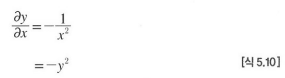   
- 식에 따르면 역전파 때는 상류에서 흘러온 값에 -y^2(순전파의 출력을 제곱한 후 마이너스를 붙인 값)을 곱해서 하류로 전달함   
- 계산 그래프에서는 다음과 같음   
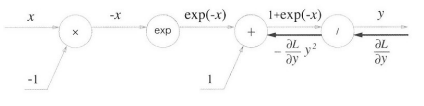   

#### 2단계
'+' 노드는 상류의 값을 여과 없이 하류로 내보내는 게 전부   
- 계산 그래프에서는 다음과 같음   
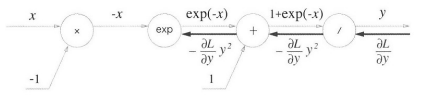   

#### 3단계
'exp' 노드는 y = exp(x) 연산을 수행하며, 그 미분은 다음과 같음   
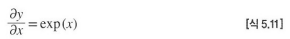   
- 계산 그래프에서는 상류의 값에 순전파 때의 출력(이 예에서는 exp(-x))을 곱해 하류로 전파함   
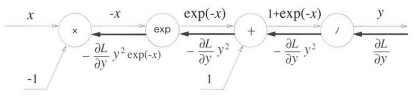   

#### 4단계
'x' 노드는 순전파 때의 값을 '서로 바꿔' 곱함   
- 이 예에서는 -1을 곱하면 됨   
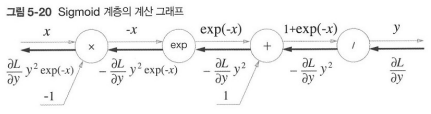   


이상으로 그림과 같이 Sigmoid 계층의 역전파를 계산 그래프로 완성함   
그림에서 보듯이 역전파의 최종 출력인 값이 하류 노드로 전파됨   
- 여기에서 를 순전파의 입력 x와 y만으로 계산할 수 있음

그래서 그림의 계산 그래프의 중간 과정을 모두 묶어 단순한 'sigmoid' 노드 하나로 대체할 수 있음   
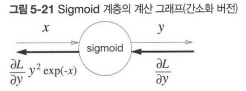   
- 계산 그래프와 간소화 버전의 결과는 똑같음   
- 그러나 간소화 버전은 역전파 과정의 중간 계산들을 생략할 수 있어 더 효율적인 계산이라 할 수 있음
- 또, 노드를 그룹화하여 Sigmoid 계층의 세세한 내용을 노출하지 않고 입력과 출력에만 집중할 수 있다는 것도 중요한 포인트
- 또한 는 다음처럼 정리해서 쓸 수 있음   
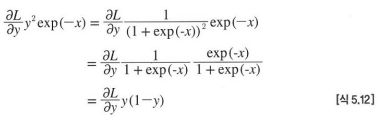   
- 이처럼 Sigmoid 계층의 역전파는 순전파의 출력(y)만으로 계산할 수 있음   
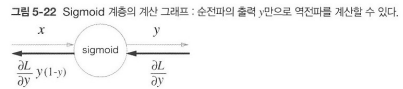   

그럼 Sigmoid 계층을 파이썬으로 구현하면

In [9]:
class Sigmoid:
    def __init__(self):
        self.out = None
    
    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        
        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

- 이 구현에서는 순전파의 출력을 인스턴스 변수 out에 보관했다가, 역전파 계산 때 그 값을 사용함

## Affine/Softmax 계층 구현하기

### Affine 계층

신경망의 순전파에서는 가중치 신호의 총합을 계산하기 때문에 행렬의 곱(넘파이에서는 np.dot())을 사용함   
- 예를 들어 파이썬으로 다음과 같은 것을 구현했었음

In [10]:
X = np.random.rand(2)  # 입력
W = np.random.rand(2,3)  # 가중치
B = np.random.rand(3)  # 편향

print(X.shape)
print(W.shape)
print(B.shape)

Y = np.dot(X, W) + B

(2,)
(2, 3)
(3,)


- 여기에서 X, W, B는 각각 형상이 (2,), (2,3), (3,)인 다차원 배열
- 그러면 뉴런의 가중치 합은 Y = np.dot(X,W) + B처럼 계산함
- 그리고 Y를 활성화 함수로 변환해 다음 층으로 전파하는 것이 신경망 순전파의 흐름이었음

복습을 조금 더 해보면, 행렬의 곱 계산은 대응하는 차원의 원소 수를 일치시키는 게 핵심   
- 예를 들어 X와 W의 곱은 아래 그림처럼 대응하는 차원의 원소 수를 일치시켜야 함   
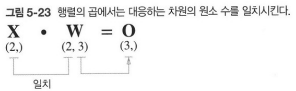   

> 신경망의 순전파 때 수행하는 행렬의 곱은 기하학에서는 **어파인 변환(affine transformation)** 이라고 함   
> 그래서 이 책에서는 어파인 변환을 수행하는 처리를 'Affine 계층'이라는 이름으로 구현함

그럼 앞에서 수행한 계산(행렬의 곱과 편향의 합)을 계산 그래프로 그리기   
- 곱을 계산하는 노드를 'dot'이라 하면 np.dot(X, W) + B 계산은 아래 그림처럼 그려짐   
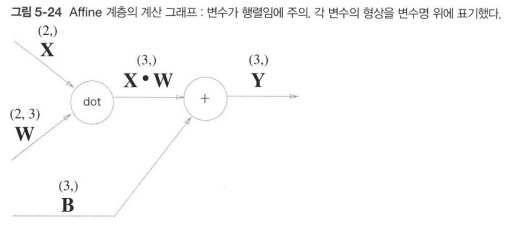   
- 또한, 각 변수의 이름 위에 그 변수의 형상도 표기함
    - 예를 들어 그림에서의 X의 형상은 (2,), X ' W의 형상은 (3,)임을 표기함   
- 이 그림은 비교적 단순한 계산 그래프
- 단, X, W, B가 행렬(다차원 배열)이라는 점에 주의
- 지금까지의 계산 그래프는 노드 사이에 '스칼라값'이 흘렀는 데 반해, 이 예에서는 '행렬'이 흐르고 있는 것

이제 그림의 역전파에 대해 생각해보면   
행렬을 사용한 역전파도 행렬의 원소마다 전개해보면 스칼라값을 사용한 지금까지의 계산 그래프와 같은 순서로 생각할 수 있음   
실제로 전개해보면 다음 식이 도출됨 (책에서 이 식으로 이끄는 과정은 생략함)   
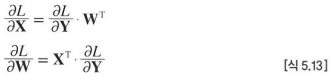   
- 식에서 의 T는 전치행렬을 뜻함
- 전치행렬은 W의 (i, j) 위치의 원소를 (j, i) 위치로 바꾼 것을 말함
- 수식으로 써보면   
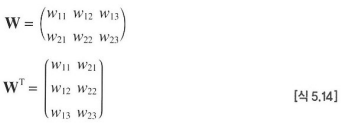   
- 위 식과 같이 W의 형상이 (2, 3)이었다면 전치행렬 의 형상은 (3, 2)가 됨

그럼 위 미분식을 바탕으로 계산 그래프의 역전파를 구해보면   
결과는 다음 그림처럼 됨   
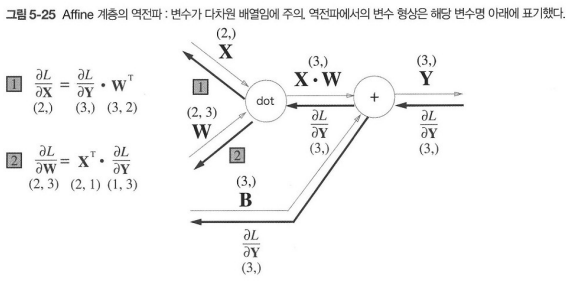   
- 그림의 계산 그래프에서는 각 변수의 형상에 주의
- 특히 X와 은 같은 형상이고, W와 도 같은 형상이라는 것을 기억하기
- X와 의 형상이 같다는 것은 다음 식을 보면 명확해짐   
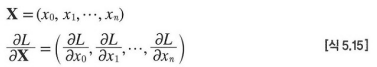   


행렬의 형상에 주의해야하는 이유는?   
행렬의 곱에서는 대응하는 차원의 원소 수를 일치시켜야 하는데, 이를 위해서는 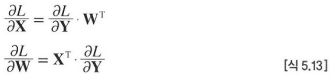을 동원해야 할 수도 있기 때문
- 예를 들어 의 형상이 (3,)이고 W의 형상이 (2, 3)일 때 의 형상이 (2,)가 되는 과 W의 곱을 생각해보면 자연히 위 식이 유도됨   
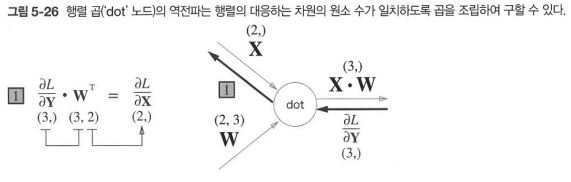

### 배치용 Affine 계층

지금까지 설명한 Affine 계층은 입력 데이터로 X 하나만을 고려한 것이었음   
이번 절에서는 데이터 N개를 묶어 순전파하는 경우, 즉 배치용 Affine 계층을 생각해봄 (묶은 데이터를 '배치'라고 부름)

배치용 Affine 계층을 계산 그래프로 그려보면   
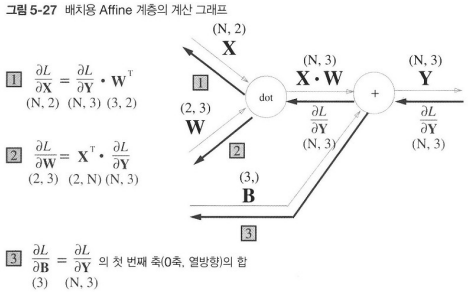   
- 기존과 다른 부분은 입력인 X의 형상이 (N, 2)가 된 것뿐
- 그 뒤로는 지금까지와 같이 계산 그래프의 순서를 따라 순순히 행렬 계산을 하게 됨
- 또, 역전파 때는 행렬의 형상에 주의하면 과 은 이전과 같이 도출할 수 있음   

편향을 더할 때도 주의해야 함   
순전파 때의 편향 덧셈은 X ' W에 대한 편향이 각 데이터에 더해짐   
- 예를 들어 N = 2 (데이터가 2개)로 한 경우, 편향은 그 두 데이터 각각에(각각의 계산 결과에) 더해짐   
구체적인 예를 살펴보면

In [11]:
X_dot_W = np.array([[0, 0, 0], [10, 10, 10]])
B = np.array([1, 2, 3])

print(X_dot_W)
print(X_dot_W + B)

[[ 0  0  0]
 [10 10 10]]
[[ 1  2  3]
 [11 12 13]]


- 순전파의 편향 덧셈은 각각의 데이터(1번째 데이터, 2번째 데이터, ...)에 더해짐   
- 그래서 역전파 때는 각 데이터의 역전파 값이 편향의 원소에 모여야 함

코드로는 다음과 같음

In [12]:
dY = np.array([[1, 2, 3], [4, 5, 6]])
print(dY)

dB = np.sum(dY, axis=0)
print(dB)

[[1 2 3]
 [4 5 6]]
[5 7 9]


- 이 예에서는 데이터가 2개(N = 2)하고 가정
- 편향의 역전파는 그 두 데이터에 대한 미분을 데이터마다 더해서 구함
- 그래서 np.sum()에서 0번째 축(데이터를 단위로 한 축)에 대해서 (axis=0)의 총합을 구하는 것

지금까지의 Affine 구현은 다음과 같음 (common/layers.py 파일의 Affine 구현은 입력 데이터가 텐서(4차원 데이터)인 경우도 고려한 것이라 다음 구현과는 약간 차이가 있음)

In [13]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(x, self.W) + self.b
        
        return out
    
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        return dx

### Softmax-with-Loss 계층

마지막으로 출력층에서 사용하는 소프트맥스 함수에 대한 설명   
앞에서 말했듯 이 소프트맥스 함수는 입력 값을 정규화하여 출력함   
- 예를 들어 손글씨 숫자 인식에서의 Softmax 계층의 출력은 다음 그림처럼 됨   
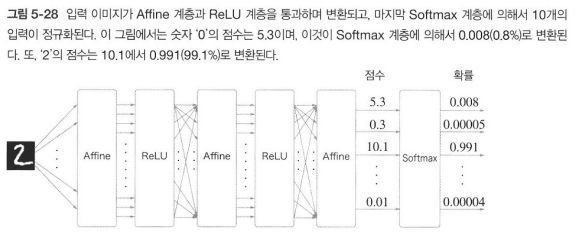   
- 그림과 같이 Softmax 계층은 입력 값을 정규화(출력의 합이 1이 되도록 변형)하여 출력함
- 또한, 손글씨 숫자는 가짓수가 10개(10클래스 분류)이므로 Softmax 계층의 입력은 10개가 됨

> 신경망에서 수행하는 작업은 **학습** 과 **추론** 두 가지   
> 추론할 때는 일반적으로 Softmax 계층을 사용하지 않음   
> 예컨대 위 그림의 신경망은 추론할 때는 마지만 Affine 계층의 출력을 인식 결과로 이용함   
> 또한, 신경망에서 정규화하지 않는 출력 결과(그림에서는 Softmax 앞의 Affine 계층의 출력)를 **점수(score)** 라 함   
> 즉, 신경망 추론에서 답을 하나만 내는 경우에는 가장 높은 점수만 알면 되니 Softmax 계층은 필요 없다는 것   
> 반면, 신경망을 학습할 때는 Softmax 계층이 필요함

이제 소프트맥스 계층을 구현할 텐데, 손실 함수인 교차 엔트로피 오차도 포함하여 'Softmax-with-Loss 계층'이라는 이름으로 구현   
먼저 Softmax-with-Loss 계층의 계산 그래프를 보면   
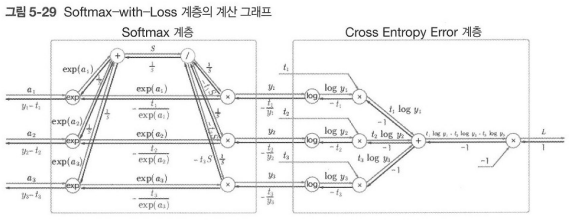   
- 보다시피 Softmax-with-Loss 계층은 다소 복잡함
- 여기에서는 결과만 제시함 - 그 도출 과정이 궁금하면 "부록 A. Softmax-with-Loss 계층의 계산 그래프"를 참고

#### 부록 A. Softmax-with-Loss 계층의 계산 그래프

이 부록에서는 소프트맥스 함수와 교차 엔트로피 오차의 계산 그래프를 그려보고, 그 역전파를 구해봄   
- 소프트맥스 함수는 'Softmax' 계층, 교차 엔트로피 오차는 'Cross Entropy Error' 계층, 이 둘을 조합한 계층을 'Softmax-with-Loss' 계층이라 함   

결과를 먼저 보면 Softmax-with-Loss 계층은 다음의 계산 그래프로 그릴 수 있음   
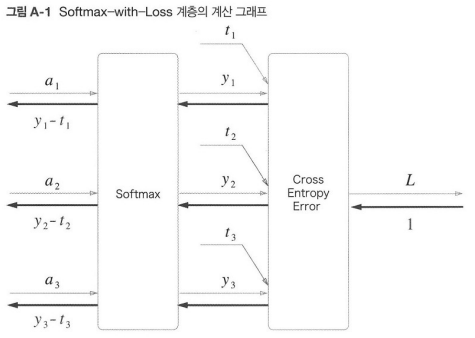   
- 그림에서는 3클래스 분류를 수행하는 신경망을 가정하고 있음 
- 이전 계층으로부의 입력은 (a1, a2, a3)이며 Softmax 계층은 (y1, y2, y3)를 출력함
- 또, 정답 레이블은 (t1, t2, t3)이며 Cross Entropy Error 계층은 손실 L을 출력함   
이 부록에서는 Softmax-with-Loss 계층의 역전파 결과가 그림처럼 (y1 - t2, y2 - t2, y3 - t3)가 됨

##### 순전파

위 그림의 계산 그래프에서는 Softmax 계층과 Cross Entropy Error 계층의 내용은 생략했음   
이번 절에서는 이 두 계층의 내용을 생략하지 않고 그리는 것부터 시작   

우선 Softmax 계층으로, 소프트맥스 함수는 수식으로는 다음과 같음   
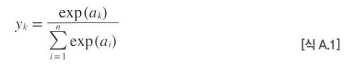   
그리고 Softmax 계층의 계산 그래프는   
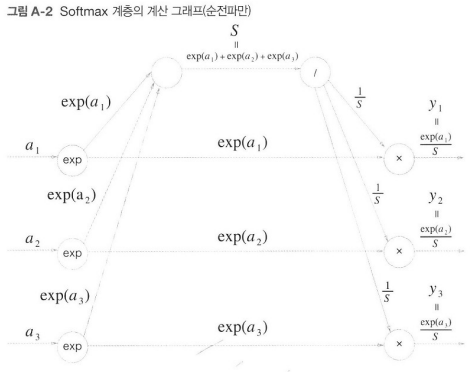   
- 그림은 지수의 합, 즉 식의 분모 항을 S로 표기함 
- 최종 출력은 (y1, y2, y3)

이어서 Cross Entropy Error 계층을 보면   
교차 엔트로피 오차의 수식은 다음과 같음   
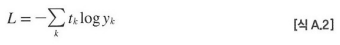   
식을 바탕으로, Cross Entropy Error 계층의 계산 그래프는   
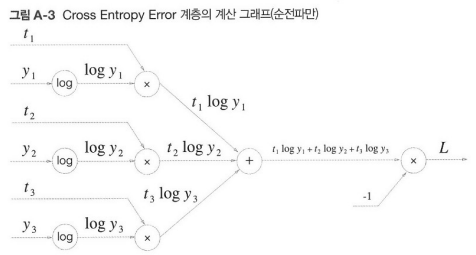   
- 그림은 식을 그대로 계산 그래프로 그린 것 - 특별히 어려운 점은 없음


##### 역전파

우선 Cross Entropy Error 계층의 역전파는   
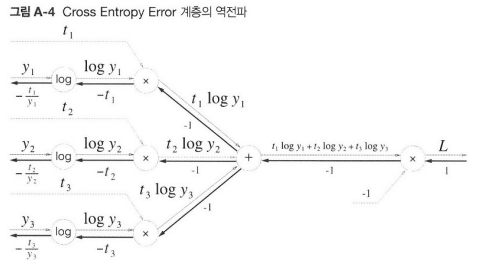   
이 계산 그래프의 역전파를 구할 때는 다음을 유념해야 함
- 역전파의 초깃값, 즉 그림의 가장 오른쪽 역전파의 값은 1 (=1 이므로)
- 'x' 노드의 역전파는 순전파 시의 입력들의 값을 '서로 바꿔' 상류의 미분에 곱하고 하류로 흘림
- '+' 노드에서는 상류에서 전해지는 미분을 그대로 흘림
- 'log' 노드의 역전파는 다음 식을 따름   
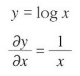   

위 규칙을 따르면 Cross Entropy Error 게층의 역전파는 쉽게 구할 수 있음   
결과는 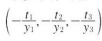이며, 이 값이 Softmax 계층으로의 역전파 입력이 됨   

이어서 Softmax 계층의 역전파   
이 계층의 역전파는 조금 복잡하니 하나하나 확인하면서 진행   
- 1단계   
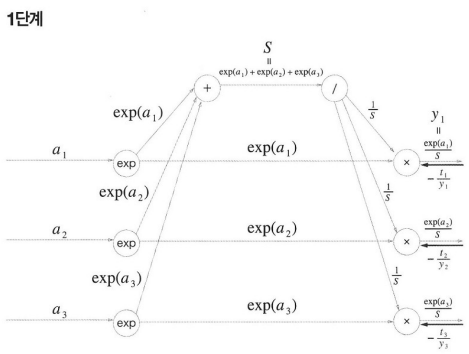   
- 앞 계층(Cross Entropy Error 계층)의 역전파 값이 흘러옴
- 2단계   
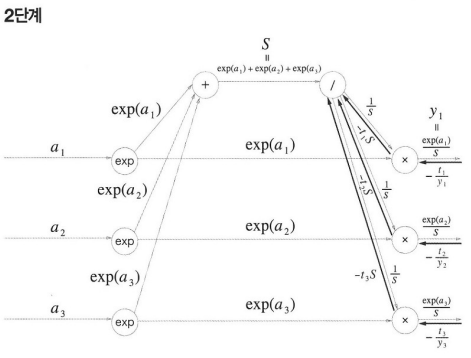   
- 'x' 노드에서는 순전파의 입력들을 '서로 바꿔' 곱함
- 여기에서는 다음 계산이 이루어짐   
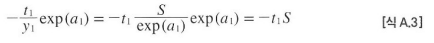   
- 3단계   
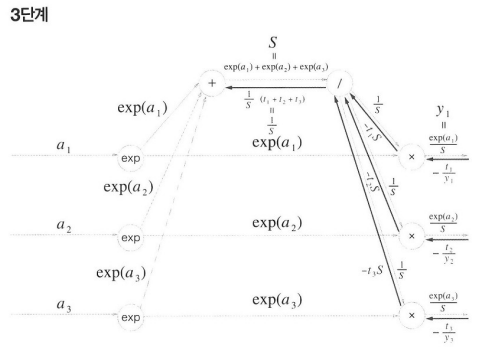   
- 순전파 때 여러 갈래로 나뉘어 흘렀다면 역전파 때는 그 반대로 흘러온 여러 값을 더함
- 그래서 여기에서는 3개의 갈라진 역전파의 값(-t1S, -t2S, -t3S)이 더해짐
- 이 더해진 값이 '/' 노드의 역전파를 거쳐 이 됨
    - '/' 노드의 역전파는 '상류에서 흘러온 값'에 '순전파 때의 출력을 제곱한 후 마이너스를 붙힌 값'을 곱해 하류로 전달함 
- 그런데 여기에서 (t1, t2, t3)은 '원-핫 벡터'로 표현된 정답 레이블
    - 원-핫 벡터란 (t1, t2, t3) 중 단 하나만 1이고 나머지는 전부 0임을 뜻함
    - 따라서 t1 + t2 + t3 = 1이 됨
- 4단계   
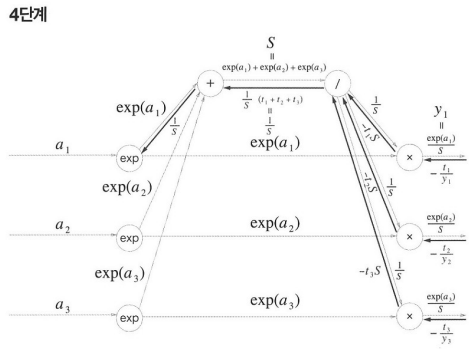   
- '+' 노드는 입력을 여과 없이 내보냄
- 5단계   
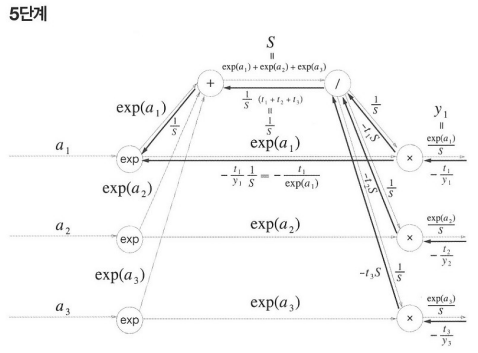   
- 'x' 노드는 입력을 '서로 바꾼' 곱셈
- 여기에서는 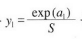를 이용해 식을 변형함
- 6단계   
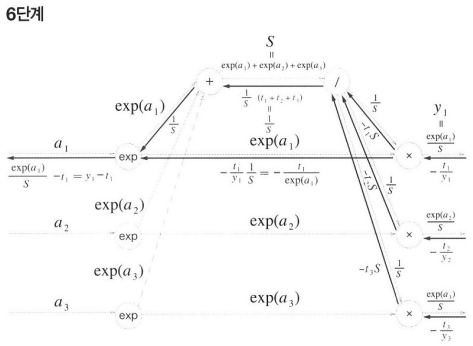   
- 'exp' 노드에서는 다음 관계식이 성립함   
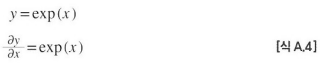   
- 그리고 두 갈래의 입력의 합에 exp(a1)을 곱한 수치가 여기에서 구하는 역전파
- 식으로 쓰면 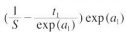이 되고, 이를 변형하면 y1 - t1이 됨

위 과정을 거쳐 순전파의 입력이 a1인 첫 번째 노드에서는 역전파가 y1 - t1임이 유도됨   
나머지 a2와 a3의 역전파도 같은 순서로 구할 수 있음   
결과는 각각 y2 - t2와 y3 - t3가 됨   
또, 여기에서 다룬 3클래스 분류 외에, 가령 n클래스 분류에서도 같은 결과가 유도되는 것은 쉽게 알아낼 수 있음


##### 정리

여기에서는 Softmax-with-Loss 계층의 계산 그래프를 생략 없이 그려가면 그 역전파를 구했음   
계산 그래프를 생략하지 않고 그리면 다음 그림처럼 됨   
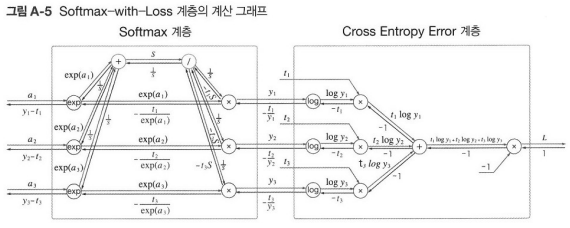   
- 복잡해 보이지만 계산 그래프로 한 단계씩 확인하면서 진행하면 미분을 구하는 것(역전파의 순서)이 그렇게 힘든 작업은 아님
- Softmax-with-Loss 계층 외에도, 배치 정규화 계층 등 복잡해 보이는 계층을 만나면 이번 절에서 한 것과 같은 과정을 꼭 해보기
- 수식만 놓고 고민하는 것보다 분명 쉽게 이해할 수 있음

이어서 간소화한 그래프를 보면   
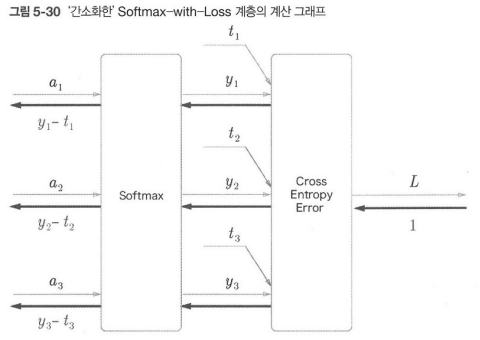   
- 그림의 계산 그래프에서 소프트맥스 함수는 'Softmax' 계층으로, 교차 엔트로피 오차는 'Cross Entropy Error' 계층으로 표기함
- 여기에서는 3클래스 분류를 가정하고 이전 게층에서 3개의 입력(점수)를 받음
- 그림과 같이 Softmax 계층은 (a1, a2, a3)를 정규화하여 (y1, y2, y3)를 출력함
- Cross Entropy Error 계층은 Softmax의 출력 (y1, y2, y3)와 정답 레이블 (t1, t2, t3)를 받고, 이 데이터들로부터 손실 L을 출력함

그림에서 주목할 것은 역전파의 결과   
- Softmax 계층의 역전파는 (y1 - t2, y2 - t2, y3 - t3)라는 '말끔한' 결과를 내놓고 있음
    - (y1, y2, y3)는 Softmax 계층의 출력이고 (t1, t2, t3)는 정답 레이블이므로 (y1 - t2, y2 - t2, y3 - t3)는 Softmax 계층의 출력과 정답 레이블의 차분인 것
- 신경망의 역전파에서는 이 차이인 오차가 앞 계층에 전해지는 것 - 이는 신경망 학습의 중요한 성질

그런데 신경망 학습의 목적은 신경망의 출력(Softmax의 출력)이 정답 레이블과 가까워지도록 가중치 매개변수의 값을 조정하는 것이었음   
그래서 신경망의 출력과 정답 레이블의 오차를 효율적으로 앞 계층에 전달해야 함   
- 앞의 (y1 - t2, y2 - t2, y3 - t3)라는 결과는 바로 Softmax 계층의 출력과 정답 레이블의 차이로, 신경망의 현재 출력과 정답 레이블의 오차를 있는 그대로 드러내는 것

> '소프트맥스 함수'의 손실 함수로 '교차 엔트로피 오차'를 사용하니 역전파가 (y1 - t2, y2 - t2, y3 - t3)로 말끔히 떨어짐   
> 사실 이런 말끔함은 우연이 아니라 교차 엔트로피 오차라는 함수가 그러게 설계되었기 때문   
> 또, 회귀의 출력층에서 사용하는 '항등 함수'의 손실 함수로 '평균 제곱 오차'를 이용하는 이유도 이와 같음   
> 즉, '항등 함수'의 손실 함수로 '평균 제곱 오차'를 사용하면 역전파의 결과가 (y1 - t2, y2 - t2, y3 - t3)로 말끔히 떨어짐

구체적인 예를 하나 보면
- 가령 정답 레이블이 (0, 1, 0)일 때 Softmax 계층이 (0.3, 0.2, 0.5)를 출력했다고 가정
- 정답 레이블을 보면 정답의 인덱스는 1
- 그런데 출력에서는 이때의 확률이 겨우 0.2(20%)라서, 이 시점의 신경망은 제대로 인식하지 못하고 있음
- 이 경우 Softmax 계층의 역전파는 (0.3, -0.8, 0.5)라는 커다란 오차를 전파함
- 결과적으로 Softmax 계층의 앞 계층들은 그 큰 오차로부터 큰 깨달음을 얻게 됨

이번에 살펴볼 예는
- 정답 레이블이 똑같이 (0, 1, 0)일 때 Softmax 계층이 (0.01, 0.99, 0)을 출력한 경우 (이 신경망은 꽤 정확히 인식하고 있음)
- 이 경우 Softmax 계층의 역전파가 보내는 오차는 비교적 작은 (0.01, -0.01, 0)
- 이번에는 앞 계층으로 전달된 오차가 작으므로 학습하는 정도도 작아짐

그럼 Softmax-with-Loss 계층을 구현한 코드를 보면

In [16]:
import sys
import os
sys.path.append(os.pardir)

from codes.functions import softmax, cross_entropy_error

class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None  # 손실
        self.y = None  # softmax의 출력
        self.t = None  # 정답 레이블(원-핫 벡터)
    
    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        return self.loss
    
    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size
        
        return dx

- 이 구현에서는 이전에 구현한 함수인 softmax()롸 cross_entropy_error()를 이용함
- 그 덕분에 이번 구현은 매우 간단
- 또, 역전파 때는 전파하는 값을 배치의 수(batch_size)로 나눠서 데이터 1개당 오차를 앞 계층으로 전파하는 점에 주의

## 오차역전파법 구현하기

앞에서 구현한 계층을 조합하면 마치 레고 블록을 조립하듯 신경망을 구축할 수 있음   
이번 절에서는 지금까지 구현한 계층을 조합해서 신경망을 구축해보기

### 신경망 학습의 전체 그림

신경망 학습의 전체 그림을 복습하기   
다음은 신경망 학습의 순서
- 전제
    - 신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정을 '학습'이라 함
    - 신경망 학습은 다음과 같이 4단계로 수행함
- 1단계 - 미니배치
    - 훈련 데이터 중 일부를 무작위로 가져옴
    - 이렇게 선별한 데이터를 미니배치라 하며, 그 미니배치의 손실 함수 값을 줄이는 것이 목표
- 2단계 - 기울기 산출
    - 미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구함
    - 기울기는 손실 함수의 값을 가장 작게 하는 방향을 제시함
- 3단계 - 매개변수 갱신
    - 가중치 매개변수를 기울기 방향으로 아주 조금 갱신
- 4단계 - 반복
    - 1 ~ 3단계를 반복

지금까지 설명한 오차역전파법이 등장하는 단계는 두 번째인 '기울기 산출'   
앞 장에서는 이 기울기를 두하기 위해서 수치 미분을 사용함   
그런데 수치 미분은 구현하기는 쉽지만 계산이 오래 걸림   
오차역전파법을 이용하면 느린 수치 미분과 달리 기울기를 효율적이고 빠르게 구할 수 있음

### 오차역전파법을 적용한 신경망 구현하기

여기에서는 2층 신경망을 TwoLayerNet 클래스로 구현함   
우선은 이 클래스의 인스턴스 변수와 메서드를 정리해보기   
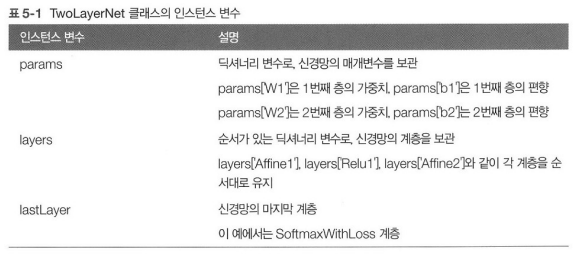   
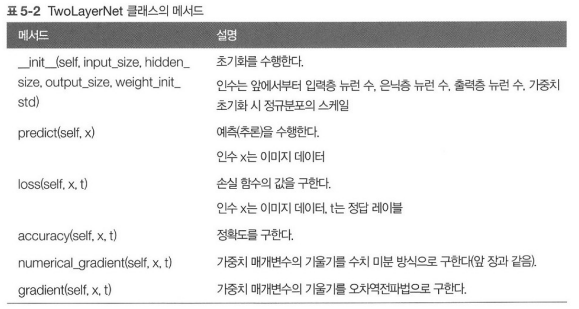   

이 클래스의 구현은 좀 길지만, 그 내용은 "4.5 학습 알고리즘 구현하기"와 공통되는 부분이 많음   
앞 장과 크게 다른 부분은 계층을 사용한다는 점   
계층을 사용함으로써 인식 결과를 얻는 처리(predict())와 기울기를 구하는 처리(gradient()) 계층의 전파만으로 동작이 이루어지는 것

In [18]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from codes.layers import *
from codes.gradient import numerical_gradient
from collections import OrderedDict

class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeors(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeors(output_size)
        
        # 계층 생성
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        
        return x
    
    # x: 입력 데이터, t: 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])

        return self.accuracy
    
    # x: 입력 데이터, t: 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)

        grads = {}
        grads['W1'] = self.numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = self.numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = self.numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = self.numerical_gradient(loss_W, self.params['b2'])
        return grads
    
    def gradient(self, x, t):
        # 순전파
        self.loss(x, t)

        # 역전파
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)
        
        # 결과 저장
        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db

        return grads

- 신경망의 계층을 OrderedDict에 보관하는 점이 중요
- OrderedDict은 순서가 있는 딕셔너리
- '순서가 있는'이란 딕셔너리에 추가한 순서를 기억한다는 것
- 그래서 순전파 때는 추가한 순서대로 각 계층의 forward() 메서드를 호출하기만 하면 처리가 완료됨
- 마찬가지로 역전파 때는 계층을 반대 순서로 호출하기만 하면 됨
- Affine 계층과 ReLU 계층이 각자의 내부에서 순전파와 역전파를 제대로 처리하고 있으니, 여기에서는 그냥 계층을 올바른 순서로 연결한 다음 순서대로 (혹은 역순으로) 호출해주면 끝

이처럼 신경망의 구성 요소를 '계층'으로 구현한 덕분에 신경망을 쉽게 구축할 수 있었음   
'계층'으로 모듈화해서 구현한 효과는 아주 큼   
- 예컨대 5층, 10층, 20층, ...과 같이 깊은 신경망을 만들고 싶다면, 단순히 필요한 만큼 계층을 더 추가하면 됨

이어서 다음 절에서는 각 계층 내부에 구현된 순전파와 역전파를 활용해 인식 처리와 학습에 필요한 기울기를 정확하게 구해봄

### 오차역전파법으로 구한 기울기 검증하기

지금까지 기울기를 구하는 방법을 두 가지 설명함   
- 하나는 수치 미분을 써서 구하는 방법
- 또 하나는 해석적으로 수식을 풀어 구하는 방법
    - 해석적 방법은 오차역전파법을 이용하여 매개변수가 많아도 효율적으로 계산할 수 있었음
- 그러니 이제부터는 느린 수치 미분 대신 오차역전파법을 사용

수치 미분은 느림   
그리고 오차역전파법을 제대로 구현해두면 수치 미분은 더 이상 필요없음   
그렇다면 수치 미분은 아무런 쓸모가 없나?   
사실 수치 미분은 오차역전파법을 정확히 구현했는지 확인하기 위해 필요함   

수치 미분의 이점은 수현하기 쉽다는 것   
그래서 수치 미분의 구현에는 버그가 숨어 있디 어려운 반면, 오차역전파법은 구현하기 복잡해서 종종 실수를 하곤 함   
그래서 수치 미분의 결과와 오차역전파법의 결과를 비교하여 오차역전파법을 제대로 구현했는지 검증하곤 함   
이처럼 두 방식으로 구한 기울기가 일치함(엄밀히 말하며 거의 같음)을 확인하는 작업을 **기울기 확인(grdient check)** 이라고 함   
기울기 확인은 다음과 같이 구현함

In [26]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

x_batch = x_train[:3]
t_batch = t_train[:3]

grad_numerical = network.numerical_gradient(x_batch, t_batch)
grad_backprop = network.gradient(x_batch, t_batch)

# 각 가중치의 차이의 절댓값을 구한 후, 그 절댓값들의 평균을 낸다.
for key in grad_numerical.keys():
    diff = np.average(np.abs(grad_backprop[key] - grad_numerical[key]))
    print(key + ":" + str(diff))

W1:4.1448669474548374e-13
b1:1.1153619911344336e-12
W2:1.4699356259972874e-11
b2:1.1990409637396836e-10


- 언제나처럼 가장 먼저 MNIST 데이터셋을 읽음
- 그리고 훈련 데이터 일부를 수치 미분으로 구한 기울기와 오차역전파법으로 구한 기울기의 오차를 확인함
- 여기에서는 각 가중치 매개변수의 차이의 절댓값을 구하고, 이를 평균한 값이 오차가 됨

위 코드의 결과는 수치 미분과 오차역전파법으로 구한 기울기의 차이가 매우 작다고 말해줌   
이로써 오차역전파법으로 구한 기울기도 올바름이 드러나면서 실수 없이 구현했다는 믿음이 커지는 것

> 수치 미분과 오차역전파법의 결과 오차가 0이 되는 일은 드뭄   
> 이는 컴퓨터가 할 수 있는 계산의 정밀도가 유한하기 때문(가령 32비트 부동소수점)   
> 이 정밀도의 한계 때문에 오차는 대부분 0이 되지는 않지만, 올바르게 구현했다면 0에 아주 가까운 작은 값이 됨   
> 만약 그 값이 크면 오차역전파법을 잘못 구현했다고 의심해봐야 함

### 오차역전파법을 사용한 핛브 구현하기

마지막으로 오차역전파법을 사용한 신경망 학습을 구현하기   
지금까지와 다른 부분은 기울기를 오차역전파법으로 구한다는 점뿐   

In [27]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from two_layer_net import TwoLayerNet

# 데이터 읽기
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 오차역전파법으로 기울기를 구한다.
    # grad = network.numerical_gradient(x_batch, t_batch)  # 수치 미분 방식
    grad = network.gradient(x_batch, t_batch)  # 오차역전파법 방식
    
    # 갱신
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(train_acc, test_acc)

0.09915 0.1009
0.78285 0.7881
0.8784666666666666 0.8818
0.8962333333333333 0.8998
0.9067 0.9109
0.91335 0.9138
0.9189833333333334 0.9194
0.9225166666666667 0.9233
0.9274666666666667 0.928
0.9297333333333333 0.93
0.9334833333333333 0.9331
0.93625 0.9349
0.93805 0.9375
0.9410833333333334 0.9395
0.9431666666666667 0.9409
0.945 0.9439
0.9464166666666667 0.9453


## 정리

이번 장에서는 계산 과정을 시각적으로 보여주는 방법인 계산 그래프를 배웠음   
계산 그래프를 이용하여 신경망의 동작과 오차역전파법을 설명하고, 그 처리 과정을 계층이라는 단위로 구현함   
- 예를 들어 ReLU 계층, Softmax-with-Loss 계층, Affine 계층, Softmax 계층 등   

모든 계층에서 forward와 backward라는 메서드를 구현함   
- forward는 데이터를 순방향으로 전파하고, backward는 역방향으로 전파함으로써 가중치 매개변수의 기울기를 효율적으로 구현할 수 있음

이처럼 동작을 계층으로 모듈화한 덕분에, 신경망의 계층을 자유롭게 조합하여 원하는 신경망을 쉽게 만들 수 있음

### 이번 장에서 배운 내용

- 계산 그래프를 이용하면 계산 과정을 시각적으로 파악할 수 있다.
- 계산 그래프의 노드는 국소적 계산으로 구성된다. 국소적 계산을 조합해 전체 게산을 구성한다.
- 계산 그래프의 순전파는 통상의 계산을 수행한다. 한편, 계산 그래프의 역전파로는 각 노드의 미분을 구할 수 있다.
- 신경망의 구성 요소를 계층으로 구현하여 기울기를 효율적으로 계산할 수 있다.(오차역전파법)
- 수치 미분과 오차역전파법의 결과를 비교하면 오차역전파법의 구현에 잘못이 없는지 확인할 수 있다.(기울기 확인)